In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/advanced-ai-for-cybersecurity-intrusion-detection-with-unsw-nb-15/UNSW_NB15_testing-set.parquet
/kaggle/input/competitions/advanced-ai-for-cybersecurity-intrusion-detection-with-unsw-nb-15/UNSW_NB15_training-set.parquet


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

test_df = pd.read_parquet('/kaggle/input/competitions/advanced-ai-for-cybersecurity-intrusion-detection-with-unsw-nb-15/UNSW_NB15_testing-set.parquet')
train_df = pd.read_parquet('/kaggle/input/competitions/advanced-ai-for-cybersecurity-intrusion-detection-with-unsw-nb-15/UNSW_NB15_training-set.parquet')

In [5]:
test_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,...,0,0,2,1,0,0,0,0,Normal,0


In [6]:
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [7]:
train_df.shape

(175341, 36)

In [8]:
test_df.shape

(82332, 36)

In [9]:
train_df.columns.tolist()

['dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'is_sm_ips_ports',
 'attack_cat',
 'label']

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

In [11]:
train_df['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [12]:
train_df['attack_cat'].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [13]:
train_df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')

In [14]:
categorical_cols = ["proto", "service", "state"]

In [15]:
for col in categorical_cols :
    print(f"\n{col}")
    print("Number of unique values:", train_df[col].nunique())
    print(train_df[col].value_counts().head(15))


proto
Number of unique values: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
swipe       201
mobile      201
pim         201
sun-nd      201
ipv6        201
rsvp        200
sep         193
Name: count, dtype: int64

service
Number of unique values: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

state
Number of unique values: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [16]:
train_df.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,...,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712055e+05,4.953000,6.948010,...,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.483313,136.887597,110.258271,1.747656e+05,1.436542e+05,165417.671875,1.883701e+08,2.423637e+06,66.005059,52.732999,...,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,...,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


In [17]:
train_df.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [18]:
train_df.duplicated().sum()

np.int64(78519)

In [19]:
test_df.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [20]:
duplicate_counts = train_df.value_counts()

print("Total unique rows:", duplicate_counts.size)
print("Total rows:", len(train_df))
print("Rows that are duplicates:", (duplicate_counts > 1).sum())
print("Maximum repetition of a single row:", duplicate_counts.max())

Total unique rows: 96822
Total rows: 175341
Rows that are duplicates: 9074
Maximum repetition of a single row: 2535


In [21]:
duplicate_rows = train_df[train_df.duplicated(keep=False)]

print("Rows involved in duplication:", len(duplicate_rows))

Rows involved in duplication: 87593


In [22]:
feature_cols = [
    col for col in train_df.columns
    if col not in ["label", "attack_cat"]
]

label_conflicts = (
    train_df.groupby(
        feature_cols,
        observed=True,
        sort=False
    )["label"]
    .nunique()
)

print(
    "Feature patterns with conflicting labels:",
    (label_conflicts > 1).sum()
)

Feature patterns with conflicting labels: 259


In [23]:
conflicting_features = label_conflicts[label_conflicts > 1]

print("Conflicting feature patterns:", len(conflicting_features))
print("Records belonging to conflicting patterns:",
      conflicting_features.index.to_frame(index=False).merge(
          train_df[feature_cols].value_counts().rename("count").reset_index(),
          on=feature_cols
      )["count"].sum())

Conflicting feature patterns: 259
Records belonging to conflicting patterns: 5585


In [24]:
train_feature_set = set(
    map(tuple, train_df[feature_cols].to_numpy())
)

test_feature_set = set(
    map(tuple, test_df[feature_cols].to_numpy())
)

overlap = train_feature_set.intersection(test_feature_set)

print("Unique training feature patterns:", len(train_feature_set))
print("Unique testing feature patterns:", len(test_feature_set))
print("Feature-pattern overlap:", len(overlap))

Unique training feature patterns: 92098
Unique testing feature patterns: 48231
Feature-pattern overlap: 1487


In [25]:
X_train_raw = train_df.drop(columns = ['attack_cat', 'label'])

In [26]:
y_train = train_df['label']

In [27]:
X_test_raw = test_df.drop(columns = ['attack_cat', 'label'])

In [28]:
y_test = test_df['label']

In [29]:
print(X_train_raw.shape)
print(y_train.shape)
print(X_test_raw.shape)
print(y_test.shape)

(175341, 34)
(175341,)
(82332, 34)
(82332,)


In [30]:
ategorical_cols = ["proto", "service", "state"]

In [31]:
numeric_cols = X_train_raw.select_dtypes(
    include=["number"]
).columns.tolist()

In [32]:
categorical_cols

['proto', 'service', 'state']

In [33]:
numeric_cols

['dur',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'is_sm_ips_ports']

In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [35]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num",
         StandardScaler(),
         numeric_cols
        ),

        ("cat",
        OneHotEncoder(handle_unknown = 'ignore'),
        categorical_cols
        )
    ]
)
print("Preprocessor created sucessfully")

Preprocessor created sucessfully


In [36]:
X_train = preprocessor.fit_transform(X_train_raw)

In [37]:
X_test = preprocessor.transform(X_test_raw)

In [38]:
print("Training Set size : ", X_train.shape)
print("Testing set Size : ", X_test.shape)

Training Set size :  (175341, 186)
Testing set Size :  (82332, 186)


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix
)

In [40]:
logistic_model = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

In [41]:
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
y_pred_lr = logistic_model.predict(X_test)
print("Predictions Done : ", len(y_pred_lr))

Predictions Done :  82332


In [43]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [44]:
print("Logistic Regression Model Results")
print("Accuracy : ", lr_accuracy)
print("Precision : ", lr_precision)
print("Recall : ", lr_recall)
print("F1 Score : ", lr_f1)

Logistic Regression Model Results
Accuracy :  0.7968833503376573
Precision :  0.7416259860475329
Recall :  0.9685211329744993
F1 Score :  0.8400218112940411


In [45]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.59      0.72     37000
           1       0.74      0.97      0.84     45332

    accuracy                           0.80     82332
   macro avg       0.84      0.78      0.78     82332
weighted avg       0.83      0.80      0.79     82332



In [46]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[21704 15296]
 [ 1427 43905]]


In [47]:
tn, fp, fn, tp = cm_lr.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 21704
False Positives: 15296
False Negatives: 1427
True Positives : 43905


In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)

In [50]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [51]:
y_pred_rf = rf_model.predict(X_test)
print("Predictions Done : ", len(y_pred_rf))

Predictions Done :  82332


In [52]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

In [53]:
print("Rondom Forest Model Results")
print("Accuracy : ", rf_accuracy)
print("Precision : ", rf_precision)
print("Recall : ", rf_recall)
print("F1 Score : ", rf_f1)

Rondom Forest Model Results
Accuracy :  0.8655808191225769
Precision :  0.8172978979535143
Recall :  0.9734845142504192
F1 Score :  0.888580144371621


In [54]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     37000
           1       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.85      0.86     82332
weighted avg       0.88      0.87      0.86     82332



In [55]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[27135  9865]
 [ 1202 44130]]


In [56]:
tn, fp, fn, tp = cm_rf.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 27135
False Positives: 9865
False Negatives: 1202
True Positives : 44130


In [57]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [58]:
from xgboost import XGBClassifier

In [59]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [60]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [61]:
y_pred_xgb = xgb_model.predict(X_test)
print("Predictions Done : ", len(y_pred_xgb))

Predictions Done :  82332


In [62]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

In [63]:
print("XG Boost Model Results")
print("Accuracy : ", xgb_accuracy)
print("Precision : ", xgb_precision)
print("Recall : ", xgb_recall)
print("F1 Score : ", xgb_f1)

XG Boost Model Results
Accuracy :  0.8698319001117427
Precision :  0.8206933610035391
Recall :  0.9770581487690815
F1 Score :  0.892075608503439


In [64]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     37000
           1       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.87     82332



In [65]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[27323  9677]
 [ 1040 44292]]


In [66]:
tn, fp, fn, tp = cm_xgb.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 27323
False Positives: 9677
False Negatives: 1040
True Positives : 44292


In [67]:
type(X_train)

scipy.sparse._csr.csr_matrix

In [68]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 186
['num__dur' 'num__spkts' 'num__dpkts' 'num__sbytes' 'num__dbytes'
 'num__rate' 'num__sload' 'num__dload' 'num__sloss' 'num__dloss'
 'num__sinpkt' 'num__dinpkt' 'num__sjit' 'num__djit' 'num__swin'
 'num__stcpb' 'num__dtcpb' 'num__dwin' 'num__tcprtt' 'num__synack'
 'num__ackdat' 'num__smean' 'num__dmean' 'num__trans_depth'
 'num__response_body_len' 'num__ct_src_dport_ltm' 'num__ct_dst_sport_ltm'
 'num__is_ftp_login' 'num__ct_ftp_cmd' 'num__ct_flw_http_mthd'
 'num__is_sm_ips_ports' 'cat__proto_3pc' 'cat__proto_a/n'
 'cat__proto_aes-sp3-d' 'cat__proto_any' 'cat__proto_argus'
 'cat__proto_aris' 'cat__proto_arp' 'cat__proto_ax.25'
 'cat__proto_bbn-rcc' 'cat__proto_bna' 'cat__proto_br-sat-mon'
 'cat__proto_cbt' 'cat__proto_cftp' 'cat__proto_chaos'
 'cat__proto_compaq-peer' 'cat__proto_cphb' 'cat__proto_cpnx'
 'cat__proto_crtp' 'cat__proto_crudp' 'cat__proto_dcn' 'cat__proto_ddp'
 'cat__proto_ddx' 'cat__proto_dgp' 'cat__proto_egp' 'cat__proto_eigrp'
 'cat__proto_em

In [69]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

num__dload               0.151779
num__swin                0.145979
num__is_sm_ips_ports     0.127734
cat__proto_arp           0.060161
num__sload               0.042905
num__tcprtt              0.038104
num__ackdat              0.034913
cat__service_dns         0.025069
cat__proto_tcp           0.024501
cat__service_-           0.023609
num__ct_dst_sport_ltm    0.022434
cat__state_CON           0.021254
cat__proto_cbt           0.020256
cat__proto_ospf          0.019878
num__rate                0.018051
dtype: float32

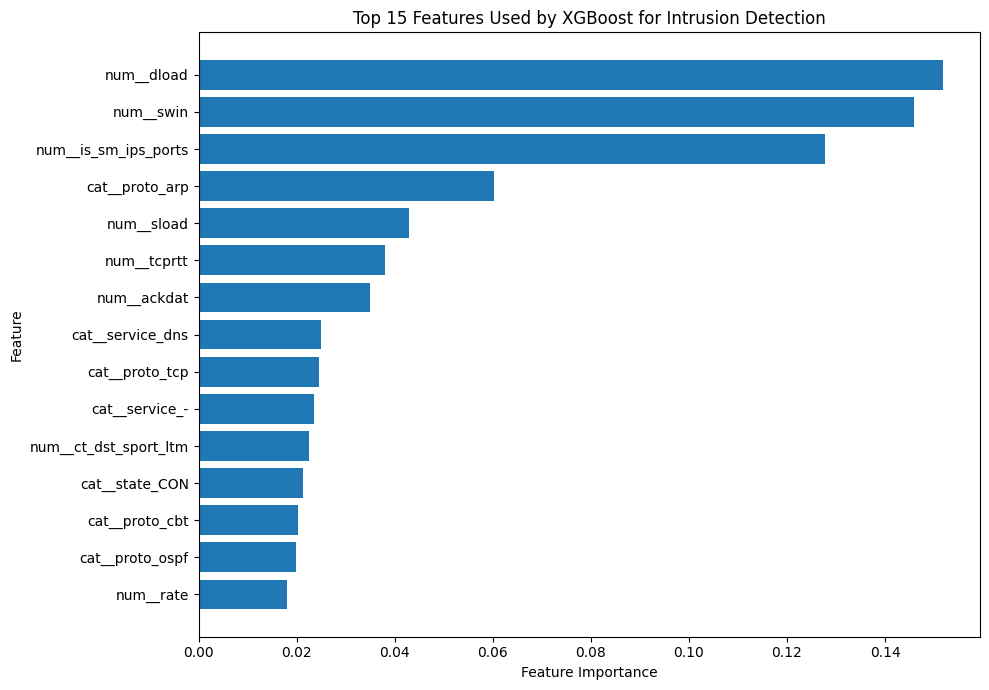

In [70]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top_features.index, top_features.values)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Used by XGBoost for Intrusion Detection")

plt.tight_layout()
plt.show()

In [71]:
comparison_df = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "False Positives": [
        15296,
        9865,
        9677
    ],
    "False Negatives": [
        1427,
        1202,
        1040
    ]
})

comparison_df

,Algorithm,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives
0,Logistic Regression,0.796883,0.741626,0.968521,0.840022,15296,1427
1,Random Forest,0.865581,0.817298,0.973485,0.888580,9865,1202
2,XGBoost,0.869832,0.820693,0.977058,0.892076,9677,1040


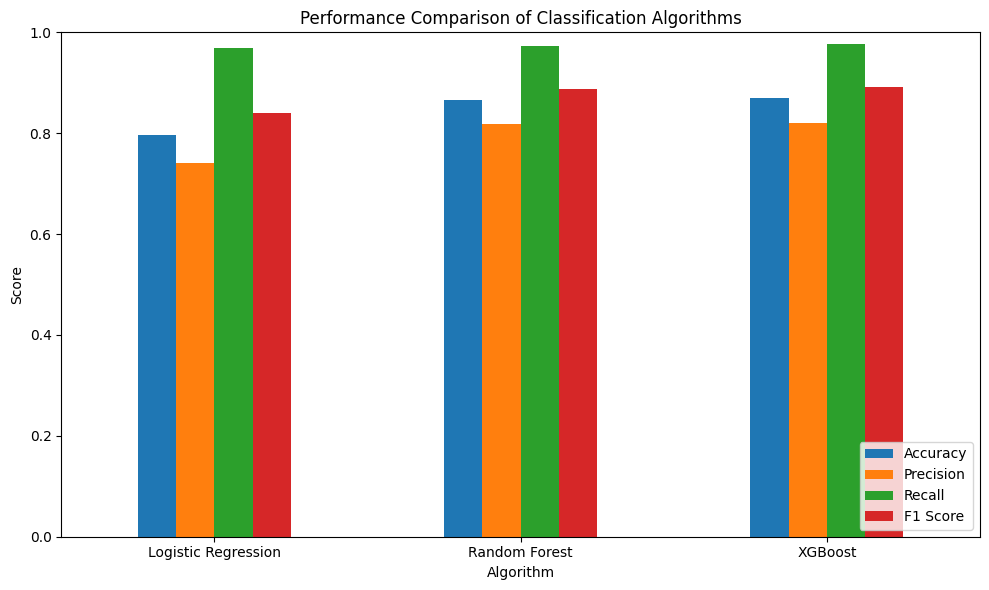

In [72]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

comparison_df.set_index("Algorithm")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Classification Algorithms")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [73]:
error_comparison = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "False Positives": [
        15296,
        9865,
        9677
    ],
    "False Negatives": [
        1427,
        1202,
        1040
    ]
})

error_comparison

,Algorithm,False Positives,False Negatives
0,Logistic Regression,15296,1427
1,Random Forest,9865,1202
2,XGBoost,9677,1040


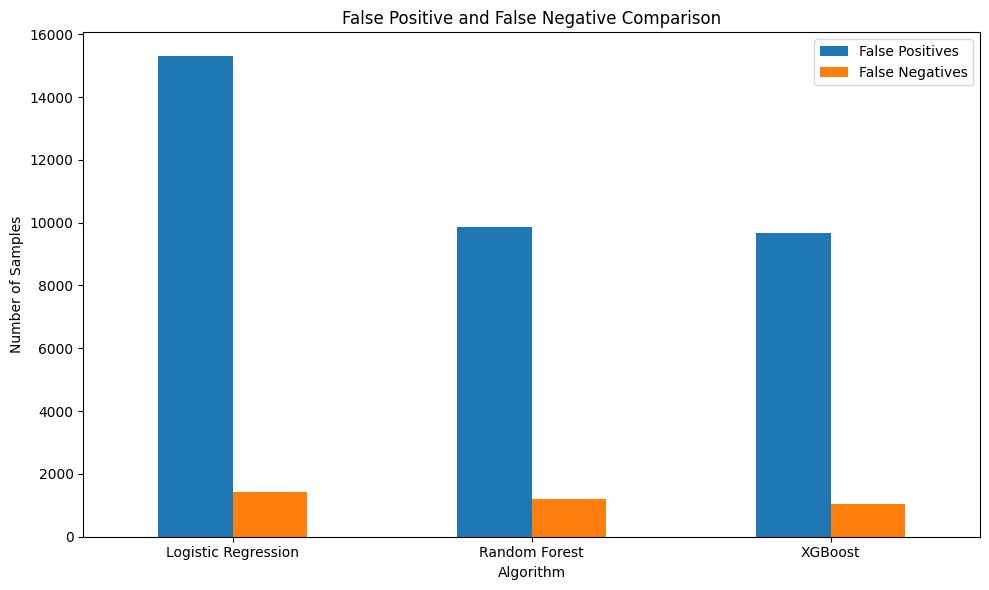

In [74]:
error_comparison.set_index("Algorithm").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("False Positive and False Negative Comparison")
plt.ylabel("Number of Samples")
plt.xlabel("Algorithm")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

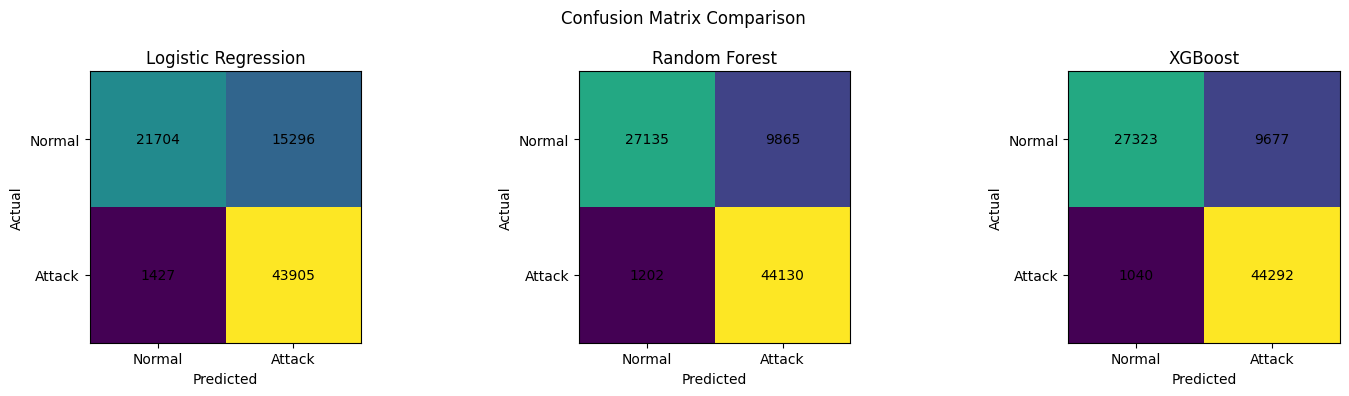

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = [cm_lr, cm_rf, cm_xgb]
names = ["Logistic Regression", "Random Forest", "XGBoost"]

for ax, cm, name in zip(axes, cms, names):

    im = ax.imshow(cm)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Normal", "Attack"])
    ax.set_yticklabels(["Normal", "Attack"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center"
            )

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()

## Final Model Selection

Based on the comparative evaluation of Logistic Regression, Random Forest, and XGBoost, the models were compared using accuracy, precision, recall, F1-score, false positives, and false negatives.

For an intrusion detection system, recall and false negatives are particularly important because failing to identify an actual attack can have serious security consequences.

Among the three evaluated algorithms, XGBoost achieved the highest overall performance. It obtained the highest accuracy, precision, recall, and F1-score while also producing the lowest number of false negatives.

Therefore, XGBoost is selected as the final model for this intrusion detection experiment.

In [76]:
best_model = "XGBoost"

best_row = comparison_df.loc[
    comparison_df["Algorithm"] == best_model
].iloc[0]

print("Selected Best Model:", best_model)
print("Accuracy :", best_row["Accuracy"])
print("Precision:", best_row["Precision"])
print("Recall   :", best_row["Recall"])
print("F1 Score :", best_row["F1 Score"])
print("False Positives:", best_row["False Positives"])
print("False Negatives:", best_row["False Negatives"])

Selected Best Model: XGBoost
Accuracy : 0.8698319001117427
Precision: 0.8206933610035391
Recall   : 0.9770581487690815
F1 Score : 0.892075608503439
False Positives: 9677
False Negatives: 1040


## Final Findings

The experimental results show that ensemble-based tree models performed better than Logistic Regression for the given intrusion detection task.

Logistic Regression achieved an accuracy of approximately 79.69% and an F1-score of 84.00%. Random Forest improved the performance considerably, achieving approximately 86.56% accuracy and an F1-score of 88.86%.

XGBoost achieved the best overall performance, with approximately 86.98% accuracy, 82.07% precision, 97.71% recall, and 89.21% F1-score.

XGBoost also produced the lowest number of false negatives (1,040), compared with 1,202 for Random Forest and 1,427 for Logistic Regression.

The results indicate that XGBoost was better able to distinguish normal network traffic from attack traffic in the evaluated dataset.

## Conclusion

This project implemented and compared three machine learning algorithms for network intrusion detection using the UNSW-NB15 dataset: Logistic Regression, Random Forest, and XGBoost.

The dataset was explored and analyzed to understand its structure, feature types, class distribution, categorical variables, numerical variables, duplicate records, and feature patterns. Appropriate preprocessing was then performed, including categorical feature encoding and transformation of the input features.

The three algorithms were trained using the same training and testing data and evaluated using accuracy, precision, recall, F1-score, confusion matrices, false positives, and false negatives.

Among the evaluated models, XGBoost achieved the best overall performance with an accuracy of 86.98% and an F1-score of 89.21%. It also achieved the highest recall of 97.71% and the lowest number of false negatives, making it the most suitable model among the three for the evaluated intrusion detection task.

The comparison demonstrates the importance of evaluating multiple machine learning algorithms rather than relying on a single model. It also shows that performance metrics such as recall and false-negative rate are particularly important in cybersecurity applications, where undetected attacks can pose significant risks.

## Limitations

Although the developed models achieved promising results, the project has several limitations:

1. The experiments were performed on the UNSW-NB15 dataset, which may not represent every type of network environment or modern cyberattack.

2. The dataset contains class and attack-category distributions that may differ from real-world network traffic.

3. The models were evaluated using a fixed training and testing dataset, and performance may vary on completely unseen real-world traffic.

4. The current experiment focuses on binary classification of network traffic as normal or attack traffic rather than detailed multi-class attack identification.

5. The selected models were evaluated using their initial configurations, and extensive hyperparameter optimization was not performed.

## Future Scope

The project can be extended in several ways:

1. **Hyperparameter Optimization:**  
   Techniques such as GridSearchCV, RandomizedSearchCV, or Bayesian optimization can be used to further improve model performance.

2. **Multi-Class Intrusion Detection:**  
   Instead of only predicting normal or attack traffic, the system can be extended to identify specific attack categories such as DoS, Exploits, Fuzzers, Reconnaissance, and Backdoor attacks.

3. **Real-Time Detection:**  
   The trained model can be integrated into a real-time network monitoring system to classify incoming network traffic.

4. **Explainable AI:**  
   SHAP or similar explainability techniques can be incorporated to understand why the model classifies a particular network connection as malicious.

5. **Deployment:**  
   The final model can be deployed using Flask or Streamlit to create an interactive intrusion detection dashboard.

6. **Continuous Learning:**  
   The system can be extended to periodically retrain the model using newly collected network traffic so that it can adapt to emerging attack patterns.

## Project Summary

This project developed a machine learning-based network intrusion detection system using the UNSW-NB15 dataset. Three classification algorithms — Logistic Regression, Random Forest, and XGBoost — were implemented and compared.

The models were evaluated using multiple performance metrics rather than accuracy alone. XGBoost achieved the best overall results with an accuracy of 86.98%, precision of 82.07%, recall of 97.71%, and F1-score of 89.21%.

Based on the experimental results, XGBoost was selected as the final model. Feature importance analysis also provided insights into the network characteristics that contributed most to the model's predictions.

The project demonstrates how machine learning can be applied to cybersecurity for detecting potentially malicious network activity.

In [77]:
comparison_df = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "False Positives": [
        15296,
        9865,
        9677
    ],
    "False Negatives": [
        1427,
        1202,
        1040
    ]
})

# Format performance metrics
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    comparison_df[col] = comparison_df[col].round(4)

comparison_df

,Algorithm,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives
0,Logistic Regression,0.7969,0.7416,0.9685,0.8400,15296,1427
1,Random Forest,0.8656,0.8173,0.9735,0.8886,9865,1202
2,XGBoost,0.8698,0.8207,0.9771,0.8921,9677,1040


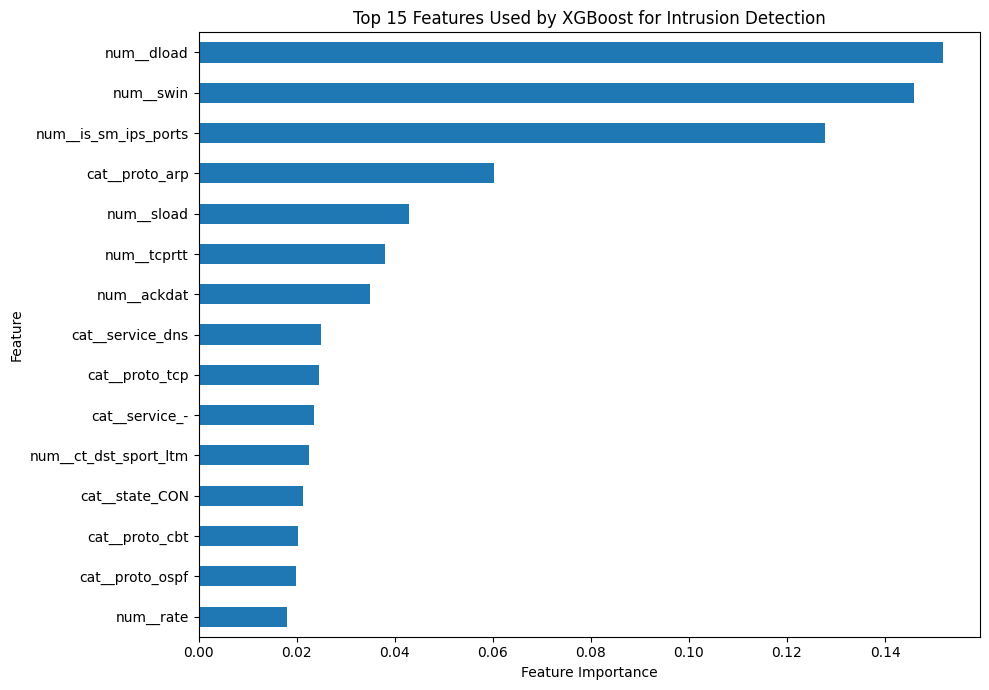

In [78]:
import matplotlib.pyplot as plt

# Get top 15 features
importance = pd.Series(
    xgb_model.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
importance.sort_values().plot(kind="barh")

plt.title("Top 15 Features Used by XGBoost for Intrusion Detection")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save high-quality image
plt.savefig("xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()